<a href="https://colab.research.google.com/github/SaraHassaan/MachineLearningWithPython-Coursera/blob/main/MultipleLinearRegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
def prepare_data(data_csv):
  df = data_csv;
  ## verify successful load with some randomly selected records
  df.sample(5)
  df.describe()
  df.dtypes
  ## Drop categoricals and any unseless columns
  df = df.select_dtypes(exclude=["object"])
  df = df.drop(['MODELYEAR'],axis=1)
  ##computes correlations between columns.
  #print(df.corr())
  ##'ENGINESIZE' and 'CYLINDERS' are highly correlated, but 'ENGINESIZE' is more correlated with the target, so we can drop 'CYLINDERS'.
  ##Similarly, each of the four fuel economy variables is highly correlated with each other. Since FUELCONSUMPTION_COMB_MPG is the most correlated with the target, you can drop the others: 'FUELCONSUMPTION_CITY,' 'FUELCONSUMPTION_HWY,' 'FUELCONSUMPTION_COMB.'
  df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',],axis=1)
  return df

In [16]:
## PLot the relationship between each pair of input features.
def plot_correlation(df):
  axes = pd.plotting.scatter_matrix(df, alpha=0.2)
  print(axes)
  # need to rotate axis labels so we can read them
  for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

  plt.tight_layout()
  plt.gcf().subplots_adjust(wspace=0, hspace=0)
  plt.show()



In [17]:
def standardize_values(X):
  ## Standardize the feature so the model doesn't favor any feature due to its magnitude
    # Standardize X,y
    X_scaler = StandardScaler()
    X_std = X_scaler.fit_transform(X)

    return X_std, X_scaler

In [18]:
#x:independent variable (feature)
#y:actual dependent variable (o/p)
def train_regression_model(X_train, y_train):
  #type(X_train), np.shape(X_train)
  ## create a model object
  model = linear_model.LinearRegression()
  ##train your model using fit
  model.fit(X_train, y_train)
  return model


In [20]:
def visualize_model(X_test, y_test, model):
  X_test = np.array(X_test)
  y_test = np.array(y_test)
  intercept_ = model.intercept_
  coef_ = model.coef_
  ##Ensure X1, X2, and y_test have compatible shapes for 3D plotting
  X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
  X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)
  ##Create a mesh grid for plotting the regression plane to form a pair of values of x1 and x2 (x1,x2) to represents two axes(x and y) in the 3d
  x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100),np.linspace(X2.min(), X2.max(), 100))
  y_surf = intercept_ + coef_[0,0] * x1_surf + coef_[0,1] * x2_surf
  ##Predict y values using trained regression model to compare with actual y_test for above/below plane colors
  y_pred = model.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else model.predict(X_test)
  above_plane = y_test >= y_pred
  below_plane = y_test < y_pred
  above_plane = above_plane[:,0]
  below_plane = below_plane[:,0]
  # Plotting
  fig = plt.figure(figsize=(20, 8))
  ax = fig.add_subplot(111, projection='3d')
  # Plot the data points above and below the plane in different colors
  ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane], label="Above Plane",s=70,alpha=.7,ec='k')
  ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane], label="Below Plane",s=50,alpha=.3,ec='k')
  # Plot the regression plane
  ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21,label='plane')
  # Set view angle
  ax.view_init(elev=10)

  # Legend
  ax.legend(fontsize='x-large', loc='upper center')

  # Remove ticks from axes
  ax.set_xticks([])
  ax.set_yticks([])
  ax.set_zticks([])

  # Set axis labels
  ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
  ax.set_ylabel('FUELCONSUMPTION', fontsize='xx-large')
  ax.set_zlabel('CO2 Emissions', fontsize='xx-large')

  # Title
  ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')

  # Aspect ratio (if you want)
  ax.set_box_aspect(None, zoom=0.75)

  # Layout
  plt.tight_layout()
  plt.show()


In [22]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")

    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

trained data length: 853
test data length: 214
Coefficients:  [[17.8581369  -5.01502179]]
Intercept:  [329.1363967]
R² Score: 0.8873
RMSE: 21.59
MAE: 14.29
MSE: 466.11


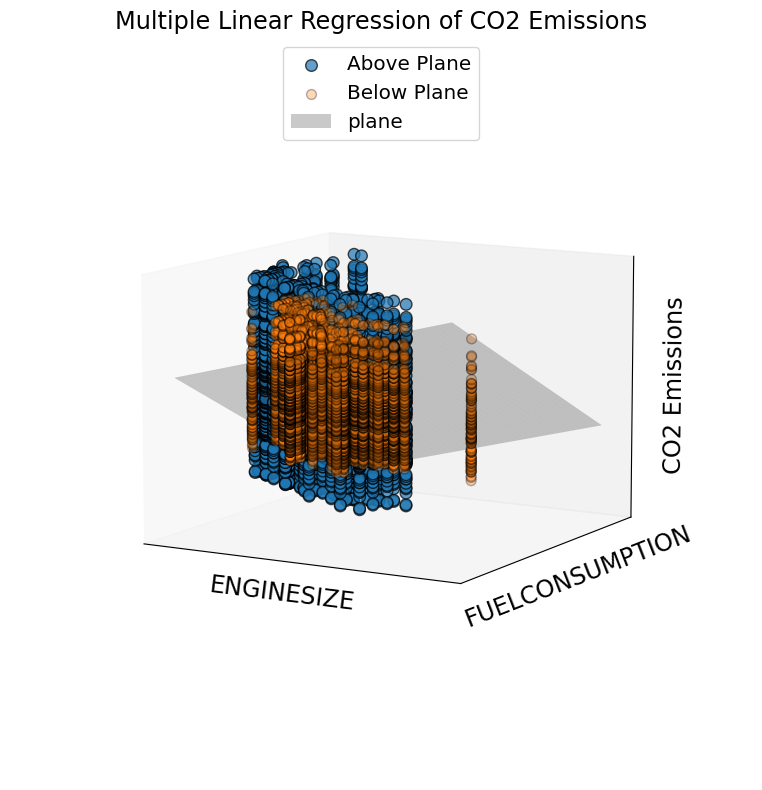

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
%matplotlib inline

url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

df = pd.read_csv(url)
df = prepare_data(df);
#print(df.dtypes)
#print(df.sample(9))
#plot_correlation(df)
X = df[['ENGINESIZE', 'FUELCONSUMPTION_COMB_MPG']]
y = df[['CO2EMISSIONS']]
#X_std, std_scaler = standardize_values(X)
X_std, x_scaler = standardize_values(X)
## Show the standardized features
#pd.DataFrame(X_std).describe().round(2)
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2,random_state=42)
print("trained data length: %i" % len(X_train))
print("test data length: %i" % len(X_test))
model = train_regression_model (X_train, y_train)
# Print the coefficients
coef= model.coef_ # two cofficients
intercept = model.intercept_
#print ('Coefficients: ',coef)
#print ('Intercept: ',intercept)
#transform your model's parameters back to the original space prior to standardization
##This gives you a proper sense of what they mean in terms of your original input features
means = x_scaler.mean_
std_devs = np.sqrt(x_scaler.var_)
# The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef / std_devs
intercept_original = intercept - np.sum((means*coef) / std_devs)
print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)
evaluate_model(model, X_test, y_test)
visualize_model(X_test, y_test , model)
